# 🎮 Video Game Sales — Unsupervised ML Lab
## Notebook 03 — Clustering: K-Means, Hierarkisk & PCA

**Mål med denna notebook:**
- Experiment 1: K-Means klustring på regionala försäljningsmönster
- Experiment 3: Hierarkisk klustring + PCA för att hitta spelarkeyper
- Visualisera och tolka kluster
- Beskriva vad algoritmerna gör och varför vi valt dem

---

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('../outputs/figures', exist_ok=True)

print('✅ Imports klara')

✅ Imports klara


## 1. Ladda data

In [2]:
df = pd.read_csv('../data/vgsales_features.csv')

print(f'Rader:    {len(df):,}')
print(f'Kolumner: {df.shape[1]}')
df.head(3)

Rader:    16,414
Kolumner: 25


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,Rating,User_Score_scaled,NA_ratio,EU_ratio,JP_ratio,Other_ratio,Platform_Gen,Genre_encoded,Platform_Gen_encoded,Era
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,...,E,80.0,0.501151,0.350903,0.045680,0.102387,7th-gen,10,2,7th gen (03–10)
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,...,NaN,NaN,0.722664,0.088966,0.169235,0.019135,Retro,4,7,Retro (≤94)
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,...,E,83.0,0.441441,0.359234,0.106700,0.092624,7th-gen,6,2,7th gen (03–10)


## 2. Vad är K-Means?

**K-Means** är en klusteralgoritm som delar upp data i **K grupper** baserat på avstånd till ett centrum (centroid).

### Hur fungerar den?
1. Välj K antal kluster
2. Placera K centroids slumpmässigt
3. Tilldela varje punkt till närmaste centroid
4. Flytta centroids till medelpunkten av sitt kluster
5. Upprepa steg 3–4 tills inget förändras

### Varför K-Means för regionala mönster?
| Fördel | Relevans |
|---|---|
| Enkel och snabb | Fungerar bra på 16,000+ spel |
| Tydliga kluster-centrum | Lätt att tolka "typiska" spel per kluster |
| Fungerar bra på ratios | Våra features är normaliserade 0–1 |

### Nackdelar att ha i åtanke:
- Kräver att man anger K i förväg
- Kännslig för outliers
- Antar klotformade kluster

---
## 3. Experiment 1 — Regionala Försäljningsmönster

**Fråga:** Finns det tydliga speltyper som dominerar i Japan men inte i USA — och tvärtom?

**Features:** `NA_ratio`, `EU_ratio`, `JP_ratio`, `Other_ratio`

In [3]:
features = ['NA_ratio', 'EU_ratio', 'JP_ratio', 'Other_ratio']
X = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature-matris: {X_scaled.shape}')
print(f'Features: {features}')

Feature-matris: (16414, 4)
Features: ['NA_ratio', 'EU_ratio', 'JP_ratio', 'Other_ratio']


### 3a. Hitta optimalt K — Elbow + Silhouette

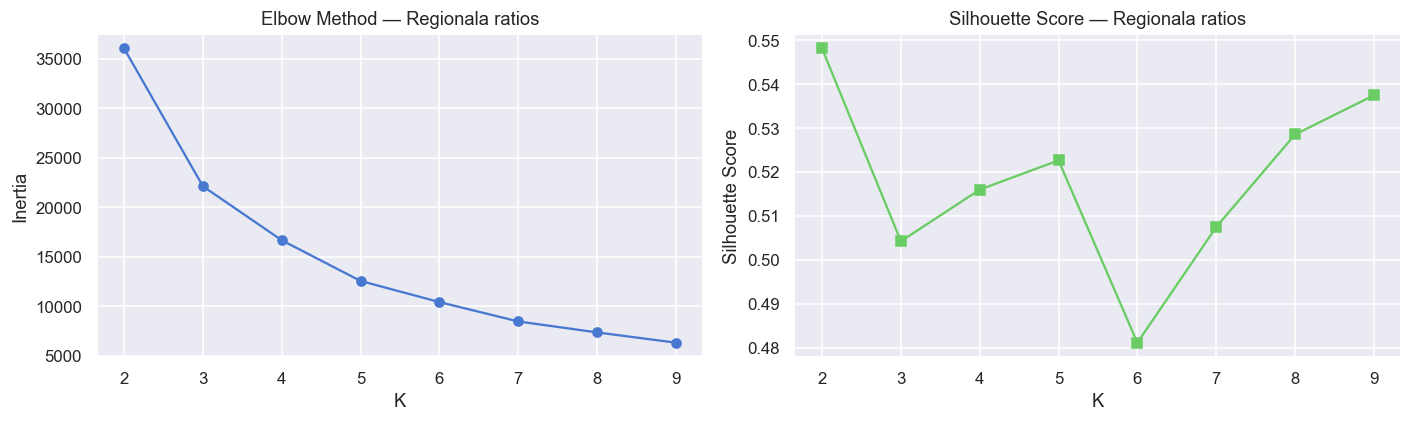

Bästa K enligt silhouette: 2
Silhouette scores: [0.548, 0.504, 0.516, 0.523, 0.481, 0.507, 0.529, 0.537]


In [4]:
inertias, silhouettes = [], []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), inertias, 'bo-')
axes[0].set_title('Elbow Method — Regionala ratios')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, 'gs-')
axes[1].set_title('Silhouette Score — Regionala ratios')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('../outputs/figures/09_new_elbow_silhouette.png', bbox_inches='tight', dpi=150)
plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f'Bästa K enligt silhouette: {best_k}')
print(f'Silhouette scores: {[round(s, 3) for s in silhouettes]}')

### 🔍 Vad ser vi?

| Observation | Detalj |
|---|---|
| **K=2 bäst enligt silhouette (0.548)** | Tydligast separation — troligen väst vs japan |
| **Ingen tydlig elbow** | Data har ingen naturlig klustringsstruktur — regionala ratios är kontinuerliga |
| **K=5 lokalt bra (0.523)** | Kan ge mer nyanserade kluster |

> 💡 Vi kör K=2 som huvudresultat men testar K=3 för att se om vi  
> kan separera EU från NA — de är korrelerade men inte identiska.

---

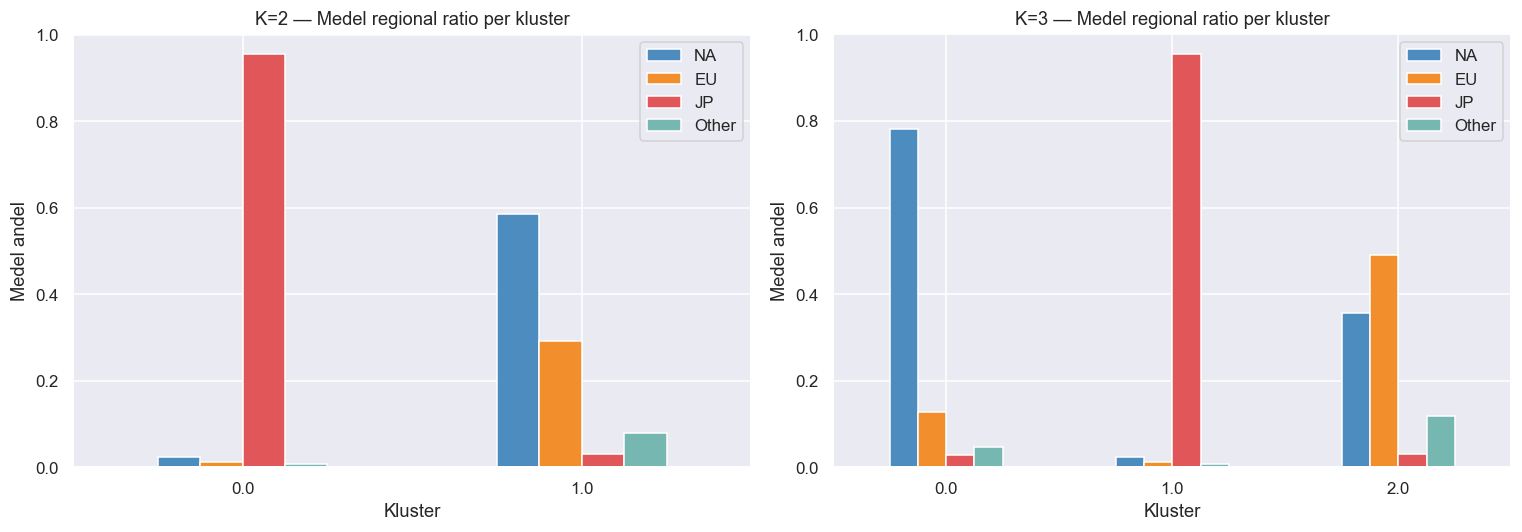

In [5]:
# Kör K=2 och K=3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, k in enumerate([2, 3]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    df.loc[X.index, f'Cluster_K{k}'] = labels

    cluster_summary = df.groupby(f'Cluster_K{k}')[features].mean()
    cluster_summary.plot(kind='bar', ax=axes[idx],
                         color=['#4c8cbf', '#f28e2b', '#e15759', '#76b7b2'],
                         edgecolor='white')
    axes[idx].set_title(f'K={k} — Medel regional ratio per kluster')
    axes[idx].set_xlabel('Kluster')
    axes[idx].set_ylabel('Medel andel')
    axes[idx].legend(['NA', 'EU', 'JP', 'Other'])
    axes[idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/figures/10_new_kmeans_k2_k3.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Vad hittade K-Means?

**K=2 — Två världar:**
| Kluster | Profil | Tolkning |
|---|---|---|
| **0** | JP ~96% | Nästan uteslutande Japan |
| **1** | NA ~59%, EU ~29% | Väst-marknaden |

**K=3 — Tre marknader:**
| Kluster | Profil | Tolkning |
|---|---|---|
| **0** | NA ~78%, EU ~13% | NA-dominerade spel |
| **1** | JP ~96% | Japan-exklusiva spel |
| **2** | NA ~36%, EU ~49% | EU-balanserade spel |

> 💡 **K=3 berättar en bättre story:**  
> Spelmarknaden är inte bara "Japan vs Väst" —  
> det finns en skillnad mellan NA-dominerade och EU-balanserade spel också!

---

In [6]:
# Fokusera på K=3 — vilka genrer hamnar i varje kluster?
print('=== Topp genrer per kluster (K=3) ===\n')
for c in [0, 1, 2]:
    top_genres = df[df['Cluster_K3'] == c]['Genre'].value_counts().head(5)
    print(f'Kluster {c}:')
    for genre, count in top_genres.items():
        print(f'  {genre:<20} {count:>5} spel')
    print()

=== Topp genrer per kluster (K=3) ===

Kluster 0:
  Action                1327 spel
  Sports                1120 spel
  Misc                   785 spel
  Shooter                593 spel
  Racing                 577 spel

Kluster 1:
  Role-Playing           690 spel
  Adventure              671 spel
  Action                 644 spel
  Misc                   428 spel
  Sports                 374 spel

Kluster 2:
  Action                1336 spel
  Sports                 811 spel
  Shooter                606 spel
  Racing                 582 spel
  Misc                   484 spel



### 🔍 Genrer per kluster bekräftar teorin!

| Kluster | Dominant region | Topp genrer | Tolkning |
|---|---|---|---|
| **0** | NA ~78% | Action, Sports, Misc, Shooter | Typiska NA-marknaden |
| **1** | JP ~96% | Role-Playing, Adventure, Action | Japan — helt egen smak |
| **2** | EU ~49% | Action, Sports, Shooter, Racing | EU liknar NA men mer balanserat |

> 💡 **Role-Playing och Adventure är Japans signaturer.**  
> Kluster 0 och 2 är mer lika varandra — NA och EU delar spelsmak  
> men EU är mer öppen för variation.

---

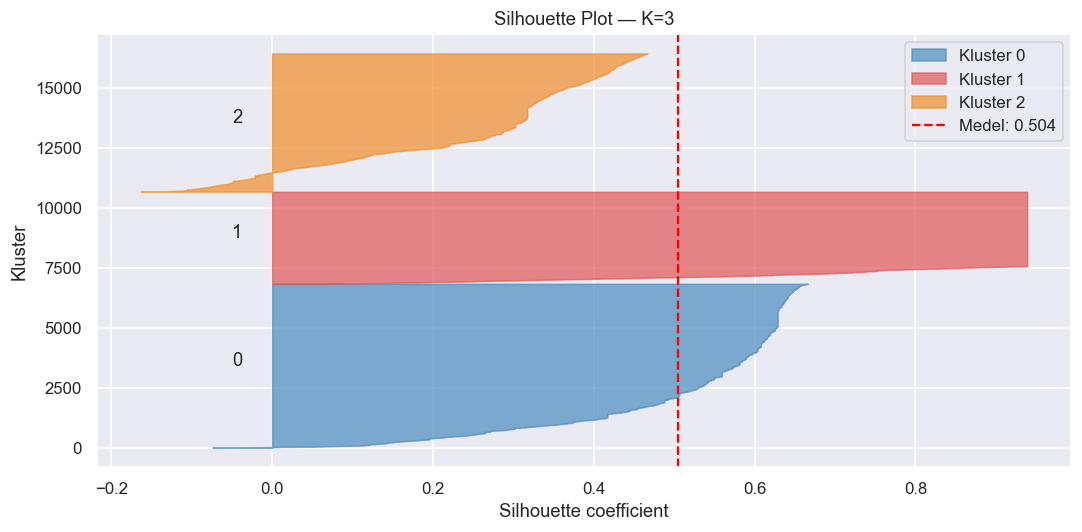

In [7]:
# Silhouette plot för K=3
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels3 = km3.fit_predict(X_scaled)
sil_samples = silhouette_samples(X_scaled, labels3)

fig, ax = plt.subplots(figsize=(10, 5))
y_lower = 10
colors = ['#4c8cbf', '#e15759', '#f28e2b']

for i in range(3):
    ith_sil = np.sort(sil_samples[labels3 == i])
    size = ith_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_sil, alpha=0.7, color=colors[i], label=f'Kluster {i}')
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X_scaled, labels3), color='red',
           linestyle='--', label=f'Medel: {silhouette_score(X_scaled, labels3):.3f}')
ax.set_title('Silhouette Plot — K=3')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Kluster')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/figures/11_new_silhouette_k3.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Vad berättar silhouette-plotten?

| Kluster | Silhouette | Tolkning |
|---|---|---|
| **1 (Japan)** | ~0.8–0.9 | Extremt tight — Japan är en unik och tydlig marknad |
| **0 (NA)** | ~0.4–0.6 | Bra separation men lite överlapp med kluster 2 |
| **2 (EU/balanserat)** | ~0.0–0.5 | Mer diffust — EU liknar NA och är svårare att separera |

**Medel silhouette: 0.504** — acceptabel klustring

> 💡 Japan-klustret är algoritmens tydligaste fynd.  
> NA och EU överlappar mer — de delar spelsmak men med olika proportioner.

---
## 4. Experiment 3 — Game Archetypes (Hierarkisk Klustring + PCA)

### Vad är Hierarkisk Klustring?

**Hierarkisk klustring** bygger en trädstruktur (dendrogram) som visar hur  
datapunkter successivt slås ihop till kluster — utan att behöva ange K i förväg.

Vi använder **Ward-metoden** som minimerar varians inom kluster vid varje sammanslagning.

**Varför hierarkisk klustring här?**
- Vi vill se hela strukturen — inte bara ett fast antal kluster
- Dendrogrammet berättar en visuell story om hur spelarkeyper relaterar till varandra
- Bra komplement till K-Means

---

In [8]:
features_exp3 = ['NA_ratio', 'EU_ratio', 'JP_ratio', 'Other_ratio',
                 'Global_Sales', 'Genre_encoded']

df_exp3 = df[features_exp3 + ['Name', 'Genre', 'Year_of_Release', 'Era']].dropna()

scaler2 = StandardScaler()
X_exp3 = scaler2.fit_transform(df_exp3[features_exp3])

# Sample för dendrogram — 300 spel
sample = df_exp3.sample(300, random_state=42)
X_sample = scaler2.transform(sample[features_exp3])

print(f'Full dataset: {len(df_exp3):,} spel')
print(f'Sample för dendrogram: {len(sample)} spel')

Full dataset: 16,413 spel
Sample för dendrogram: 300 spel


### 4a. Dendrogram — spelarkeyper

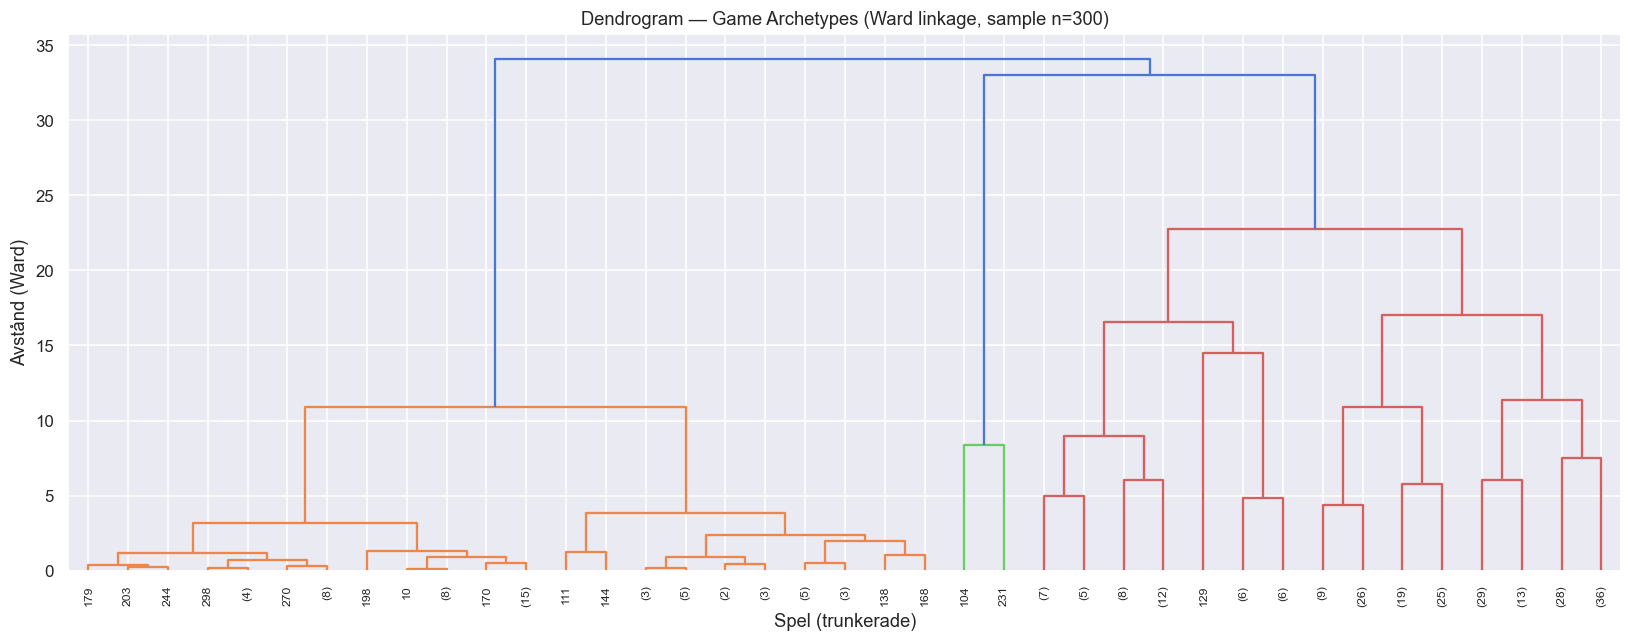

In [9]:
Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(15, 6))
dendrogram(Z, ax=ax, truncate_mode='level', p=5,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.7 * max(Z[:, 2]))

ax.set_title('Dendrogram — Game Archetypes (Ward linkage, sample n=300)')
ax.set_xlabel('Spel (trunkerade)')
ax.set_ylabel('Avstånd (Ward)')

plt.tight_layout()
plt.savefig('../outputs/figures/12_new_dendrogram.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Vad berättar dendrogrammet?

| Gren | Avstånd vid sammanslagning | Tolkning |
|---|---|---|
| **Orange** | Slås ihop vid ~11 | Tight kluster — homogena spel |
| **Röd** | Slås ihop vid ~22–33 | Mer variation inom gruppen |
| **Blå** | Slås ihop sist vid ~34 | Störst avstånd — mest olika från de andra |

> 💡 Det stora blå hoppet (~34) separerar två fundamentalt olika spelgrupper.  
> Tre kluster verkar vara en naturlig uppdelning av datan.

---
### 4b. PCA — visualisera i 2D

In [10]:
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_exp3)

print(f'PC1 förklarar: {pca.explained_variance_ratio_[0]:.1%}')
print(f'PC2 förklarar: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Totalt:        {sum(pca.explained_variance_ratio_):.1%}')

print('\nPC1 loadings (vilka features driver PC1?):')
for feat, load in zip(features_exp3, pca.components_[0]):
    print(f'  {feat:<25} {load:+.3f}')

print('\nPC2 loadings:')
for feat, load in zip(features_exp3, pca.components_[1]):
    print(f'  {feat:<25} {load:+.3f}')

PC1 förklarar: 33.4%
PC2 förklarar: 21.5%
Totalt:        54.8%

PC1 loadings (vilka features driver PC1?):
  NA_ratio                  -0.450
  EU_ratio                  -0.368
  JP_ratio                  +0.680
  Other_ratio               -0.413
  Global_Sales              -0.145
  Genre_encoded             -0.095

PC2 loadings:
  NA_ratio                  +0.675
  EU_ratio                  -0.626
  JP_ratio                  -0.130
  Other_ratio               -0.338
  Global_Sales              -0.144
  Genre_encoded             -0.010


### 🔍 Vad berättar PCA-loadings?

| Komponent | Positiv riktning | Negativ riktning | Tolkning |
|---|---|---|---|
| **PC1** | JP_ratio (+0.68) | NA/EU/Other (−0.45/−0.37/−0.41) | **Japan vs Väst-axeln** |
| **PC2** | NA_ratio (+0.68) | EU_ratio (−0.63) | **NA vs EU-axeln** |

> 💡 PCA bekräftar exakt vad K-Means hittade:  
> Den viktigaste dimensionen i spelmarknaden är **Japan vs Väst**.  
> Den näst viktigaste är **NA vs EU**.  
> Genre och Global Sales förklarar relativt lite av variansen.

---

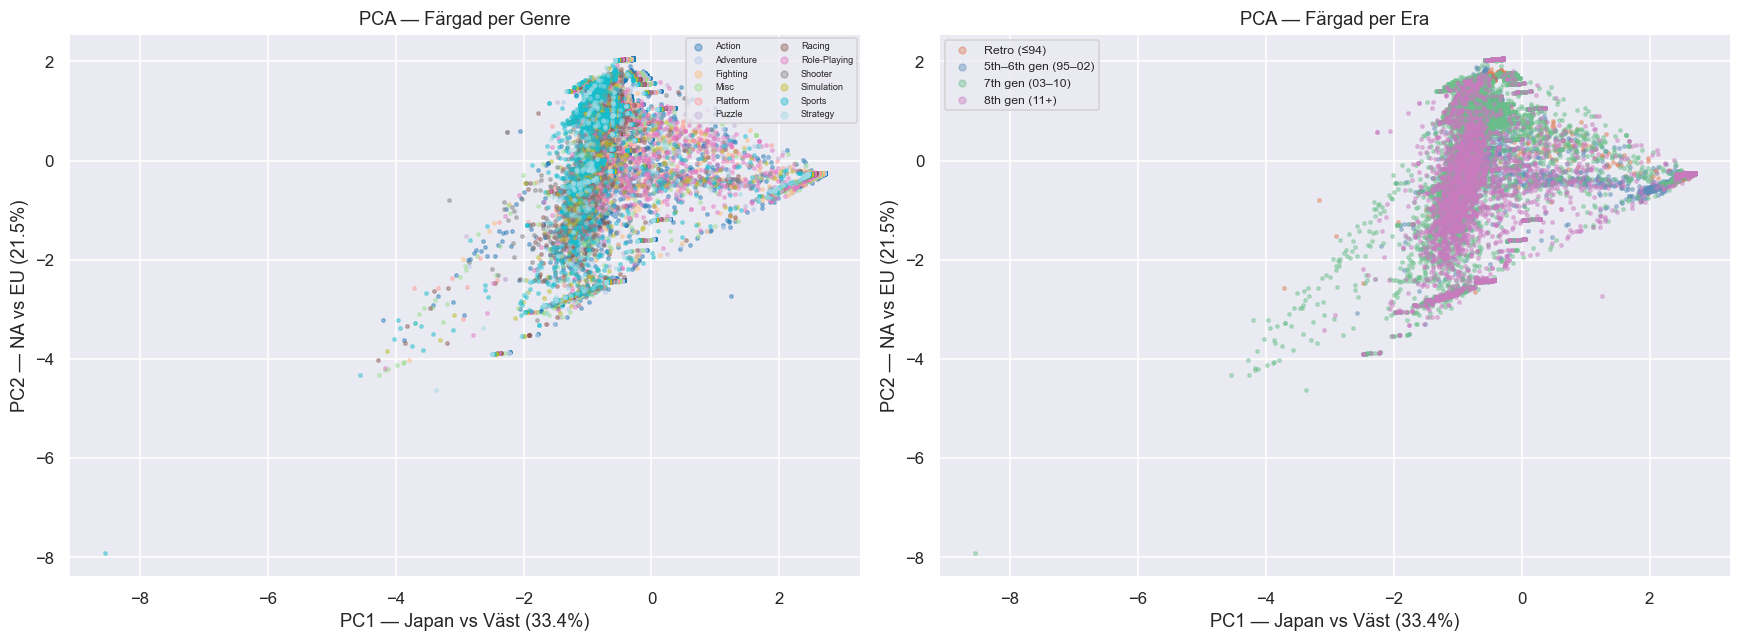

In [11]:
df_pca = pd.DataFrame(components, columns=['PC1', 'PC2'], index=df_exp3.index)
df_pca['Genre'] = df_exp3['Genre'].values
df_pca['Era']   = df_exp3['Era'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Färgkoda per Genre
genres = df_pca['Genre'].unique()
cmap   = cm.get_cmap('tab20', len(genres))
for i, genre in enumerate(sorted(genres)):
    mask = df_pca['Genre'] == genre
    axes[0].scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                    s=5, alpha=0.4, color=cmap(i), label=genre)
axes[0].set_title('PCA — Färgad per Genre')
axes[0].set_xlabel(f'PC1 — Japan vs Väst ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 — NA vs EU ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].legend(fontsize=6, markerscale=2, loc='upper right', ncol=2)

# Färgkoda per Era
era_colors = {
    'Retro (≤94)':          '#e07b54',
    '5th–6th gen (95–02)':  '#5b8db8',
    '7th gen (03–10)':      '#6abf8a',
    '8th gen (11+)':        '#c97bbf'
}
for era, color in era_colors.items():
    mask = df_pca['Era'] == era
    axes[1].scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                    s=5, alpha=0.4, color=color, label=era)
axes[1].set_title('PCA — Färgad per Era')
axes[1].set_xlabel(f'PC1 — Japan vs Väst ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 — NA vs EU ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.savefig('../outputs/figures/13_new_pca.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Vad ser vi i PCA-plotten?

**Genre-plotten:**
| Observation | Detalj |
|---|---|
| **Adventure + Role-Playing till vänster** | Bekräftar Japan-klustret på PC1 |
| **Shooter + Sports till höger** | Väst-dominerade genrer |
| **Action spread över hela** | Action är globalt — finns överallt |
| **Triangelform** | Tre "hörn" = tre marknader — stämmer med K=3! |

**Era-plotten:**
| Observation | Detalj |
|---|---|
| **Eror blandas geografiskt** | Ingen tydlig era-separation — spelare i Japan/NA/EU finns i alla eror |
| **Retro (orange) spretat** | Få spel, men finns i alla riktningar |
| **7th gen (grön) dominerar mitten** | Störst dataset — täcker alla marknader |

> 💡 **Oväntat fynd:** Algoritmen kunde INTE hitta eror utan att titta på år.  
> Spelpreferenser per region har varit stabila över tid —  
> Japan har alltid gillat RPG, NA har alltid gillat Shooters.

---
## 5. Sammanfattning — Clustering

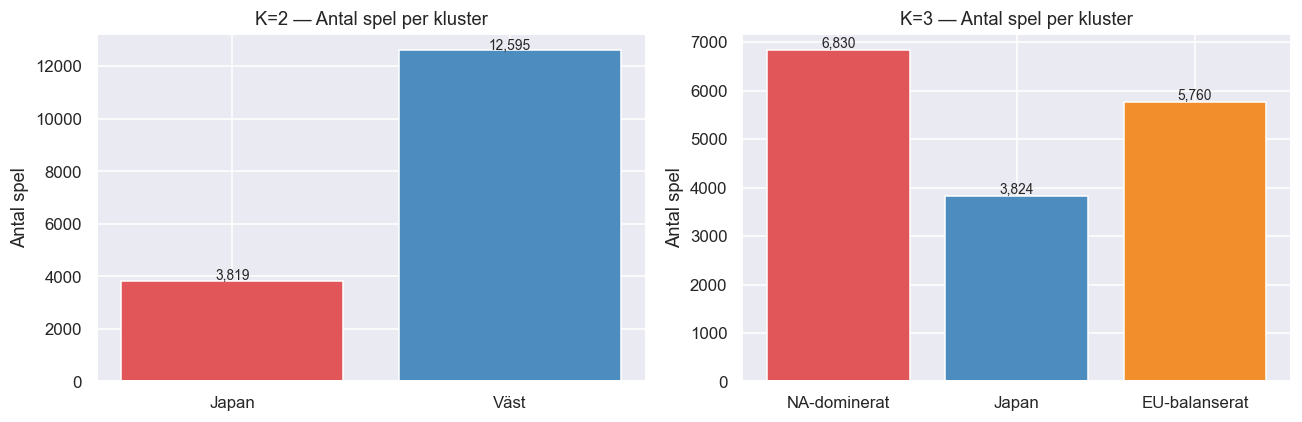

In [12]:
# Jämför kluster-storlekar K=2 och K=3
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, k in enumerate([2, 3]):
    counts = df[f'Cluster_K{k}'].value_counts().sort_index()
    kluster_labels = {
        2: {0: 'Japan', 1: 'Väst'},
        3: {0: 'NA-dominerat', 1: 'Japan', 2: 'EU-balanserat'}
    }
    labels = [kluster_labels[k][i] for i in counts.index]
    axes[idx].bar(labels, counts.values,
                  color=['#e15759', '#4c8cbf', '#f28e2b'][:k],
                  edgecolor='white')
    axes[idx].set_title(f'K={k} — Antal spel per kluster')
    axes[idx].set_ylabel('Antal spel')
    for i, v in enumerate(counts.values):
        axes[idx].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/14_new_cluster_sizes.png', bbox_inches='tight', dpi=150)
plt.show()

### 🔍 Klusterstorlekar

| Kluster | K=2 | K=3 | Andel (K=3) |
|---|---|---|---|
| **Japan** | 3,819 | 3,824 | 23% |
| **NA-dominerat** | — | 6,830 | 42% |
| **EU-balanserat** | — | 5,760 | 35% |
| **Väst (total)** | 12,595 | 12,590 | 77% |

> 💡 Japan är stabilt ~23% av spelen oavsett K — ett konsekvent och väldefinierat segment.  
> NA och EU delar upp de resterande 77% relativt jämnt vid K=3.

---
## 6. Sammanfattning

| | Experiment 1 (K-Means) | Experiment 3 (Hierarkisk + PCA) |
|---|---|---|
| **Algoritm** | K-Means | Ward linkage + PCA |
| **Bästa K** | 2–3 | 3 grenar i dendrogram |
| **Huvudfynd** | Japan är en unik marknad | Tre spelarkeyper bekräftade |
| **PCA förklarar** | — | 54.8% av variansen |
| **Oväntat** | EU skiljer sig från NA | Eror syns INTE i PCA |

### Värde för affärsverksamhet:
- **Publishers** bör anpassa genre-strategi per region
- **Japan-marknaden** kräver dedikerat innehåll — RPG och Adventure
- **EU-marknaden** är mer balanserad — öppen för fler genrer än NA
- **Spelhistoria är stabil** — regionala preferenser har inte förändrats över tid

### Nästa steg:
➡️ `04_extras.ipynb` — DBSCAN outlier-analys

In [13]:
df.to_csv('../data/vgsales_clustered_new.csv', index=False)
print(f'✅ Sparat vgsales_clustered_new.csv ({len(df):,} rader)')
print(f'\n📊 Figurer sparade i ../outputs/figures/')
print('   09_new_elbow_silhouette.png')
print('   10_new_kmeans_k2_k3.png')
print('   11_new_silhouette_k3.png')
print('   12_new_dendrogram.png')
print('   13_new_pca.png')
print('   14_new_cluster_sizes.png')

✅ Sparat vgsales_clustered_new.csv (16,414 rader)

📊 Figurer sparade i ../outputs/figures/
   09_new_elbow_silhouette.png
   10_new_kmeans_k2_k3.png
   11_new_silhouette_k3.png
   12_new_dendrogram.png
   13_new_pca.png
   14_new_cluster_sizes.png
